# 🔄 Sentiment Classification Pipeline (RoBERTa Fine‑Tuning)

Raw review text  
      │  
      ▼  
**RoBERTa byte-level BPE tokenizer** (`roberta-base`, vocab = 50,265)  
→ `<s>` tokens … `</s>` `<pad>` … (truncate/pad to 256)  
      │  
      ▼  
**Inputs:**  
- `input_ids` (batch × 256)  
- `attention_mask` (batch × 256)  

---

┌───────────────────────────────────────────────┐  
│ **RoBERTa-base encoder (pre-trained)**        │  
│ • Token + position embeddings                 │  
│ • 12 Transformer layers                       │  
│   – 12 attention heads                        │  
│   – Hidden size = 768                         │  
│ • ~125M parameters, all fine‑tuned            │  
└───────────────────────────────────────────────┘  

      │  
      ▼  
**`<s>` vector** (batch × 768)  
      │  
      ▼  
**Classification head** (new, randomly initialized):  
Dropout (p = 0.1) → Linear (768 → 768) + tanh → Dropout (p = 0.1) → Linear (768 → 2)  
      │  
      ▼  
**Logits** (batch × 2)  
      │  
      ▼  
**Prediction:** `argmax` → 0 = negative, 1 = positive


# ⚙️ Training Configuration

| Component   | Details                                                                 |
|-------------|-------------------------------------------------------------------------|
| **Input**   | Token IDs + attention mask, each of shape (batch × 256)                 |
| **Output**  | 2 logits per review → predicted label (0 = negative, 1 = positive)      |
| **Loss**    | Cross-entropy                                                           |
| **Optimiser** | AdamW, LR = 2e-5, weight decay = 0.01                                 |
| **Schedule** | Linear warm-up (10% of steps), then linear decay to 0                  |
| **Batch Size** | 16                                                                   |
| **Epochs**  | Up to 8; keep the epoch with the best validation macro-F1               |
| **Other**   | Gradient clipping = 1.0, fp16 mixed precision, deterministic mode, seed = 42 |
| **Data**    | 6,660 training / 741 validation reviews (stratified 90/10 split of train.json) |


<b>Import Libraries<b>

In [1]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

In [2]:
SEED = 0
MODEL_NAME = 'roberta-base'
MAX_LEN = 256 #Can Change this value to 512 if you have enough GPU memory

In [3]:
train_df = pd.read_json('../Dataset/train.json')
print(train_df.shape)

(7401, 2)


In [4]:
train_df.head()

,reviews,sentiments
0,I bought this belt for my daughter in-law for ...,1
1,The size was perfect and so was the color. It...,1
2,"Fits and feels good, esp. for doing a swim rac...",1
3,These socks are absolutely the best. I take pi...,1
4,Thank you so much for the speedy delivery they...,1


In [5]:
test_df = pd.read_json('../Dataset/test.json')
print(test_df.shape)

(1851, 1)


In [6]:
test_df.head()

,reviews
0,I bought 2 sleepers. sleeper had holes in the...
1,I dare say these are just about the sexiest th...
2,"everything about the transaction (price, deliv..."
3,"Not bad for just a shirt. Very durable, and m..."
4,These are truly wrinkle free and longer than t...


<b>Using RoBERTa as Tokenizer<b>

In [7]:
# 90/10 split, stratified so both keep the same 85/15 positive/negative ratio
tr_df, val_df = train_test_split(train_df, test_size=0.1,
                                 stratify=train_df['sentiments'], random_state=SEED)
print(tr_df.shape, val_df.shape)

(6660, 2) (741, 2)


In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def encode(texts):
    return tokenizer(list(texts), padding='max_length', truncation=True,
                     max_length=MAX_LEN, return_tensors='pt')

tr_enc   = encode(tr_df['reviews'])
val_enc  = encode(val_df['reviews'])
test_enc = encode(test_df['reviews'])

print(tr_enc['input_ids'].shape, val_enc['input_ids'].shape, test_enc['input_ids'].shape)
print(tokenizer.convert_ids_to_tokens(tr_enc['input_ids'][0][:20]))

torch.Size([6660, 256]) torch.Size([741, 256]) torch.Size([1851, 256])
['[CLS]', 'this', 'sleeve', '##less', 'tank', 'from', 'ck', 'is', 'one', 'of', 'the', 'best', 'i', "'", 've', 'tried', '-', 'its', 'soft', 'cotton']


<b>IMPORT and Hyperparameters<b>

In [ ]:
import random, time
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from transformers import AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

DETERMINISTIC = False   # True = bit-for-bit reproducible runs

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = DETERMINISTIC
    torch.backends.cudnn.benchmark = not DETERMINISTIC
    torch.use_deterministic_algorithms(DETERMINISTIC)
set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

BATCH_SIZE = 16
EPOCHS = 8
LR = 2e-5

cuda


# ⚙️ Training Settings

| Setting       | What it Controls                                                                 | Sensible Range        |
|---------------|----------------------------------------------------------------------------------|-----------------------|
| **SEED**      | Random initialization for reproducibility. Ensures results can be replicated.    | Any fixed integer     |
| **BATCH_SIZE**| How many reviews the model looks at before each adjustment (depends on GPU memory). Smaller = more updates, larger = smoother updates but higher memory use. | 16 or 32              |
| **EPOCHS**    | How many full passes through the training set. Too few = underfitting, too many = plateau/overfitting. | 2–8                   |
| **LR**        | How big each adjustment is (learning rate). Most critical hyperparameter for BERT fine‑tuning. | 2e‑5, 3e‑5, 5e‑5      |


<b>Load Datasets<b>

In [10]:
tr_ds   = TensorDataset(tr_enc['input_ids'],  tr_enc['attention_mask'],  torch.tensor(tr_df['sentiments'].values))
val_ds  = TensorDataset(val_enc['input_ids'], val_enc['attention_mask'], torch.tensor(val_df['sentiments'].values))
test_ds = TensorDataset(test_enc['input_ids'], test_enc['attention_mask'])

tr_loader   = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True, generator=torch.Generator().manual_seed(SEED))
val_loader  = DataLoader(val_ds,  batch_size=64)
test_loader = DataLoader(test_ds, batch_size=64)

In [11]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(tr_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, int(0.1 * total_steps), total_steps)
loss_fn = torch.nn.CrossEntropyLoss()
scaler = torch.amp.GradScaler(enabled=device.type == 'cuda')

@torch.no_grad()
def predict(loader):
    model.eval(); preds = []
    for batch in loader:
        ids, mask = batch[0].to(device), batch[1].to(device)
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=device.type == 'cuda'):
            logits = model(input_ids=ids, attention_mask=mask).logits
        preds.append(logits.argmax(-1).cpu())
    return torch.cat(preds).numpy()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


<b>Training Loop<b>

In [ ]:
best_f1, best_state, history = 0, None, []
cms = []
y_val = val_df['sentiments'].values

for epoch in range(1, EPOCHS + 1):
    model.train(); total_loss = 0; t0 = time.time()
    for ids, mask, labels in tr_loader:
        ids, mask, labels = ids.to(device), mask.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=device.type == 'cuda'):
            loss = loss_fn(model(input_ids=ids, attention_mask=mask).logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update(); scheduler.step()
        total_loss += loss.item()

    val_pred = predict(val_loader)
    acc, f1 = accuracy_score(y_val, val_pred), f1_score(y_val, val_pred, average='macro')
    history.append((epoch, total_loss / len(tr_loader), acc, f1))
    cms.append(confusion_matrix(y_val, val_pred, labels=[0, 1]))
    print(f'Epoch {epoch}: train loss {total_loss/len(tr_loader):.4f} | val acc {acc:.4f} | val macro-F1 {f1:.4f} | {time.time()-t0:.0f}s')

    if f1 > best_f1:   # keep the best epoch, not the last
        best_f1 = f1
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

model.load_state_dict(best_state)
print(classification_report(y_val, predict(val_loader), target_names=['negative', 'positive'], digits=4))


Epoch 1: train loss 0.3093 | val acc 0.9609 | val macro-F1 0.9217 | 76s
Epoch 2: train loss 0.1186 | val acc 0.9622 | val macro-F1 0.9191 | 76s
Epoch 3: train loss 0.0535 | val acc 0.9595 | val macro-F1 0.9217 | 77s
Epoch 4: train loss 0.0279 | val acc 0.9582 | val macro-F1 0.9130 | 82s
Epoch 5: train loss 0.0087 | val acc 0.9609 | val macro-F1 0.9172 | 78s
Epoch 6: train loss 0.0038 | val acc 0.9609 | val macro-F1 0.9199 | 82s
Epoch 7: train loss 0.0036 | val acc 0.9582 | val macro-F1 0.9150 | 85s
Epoch 8: train loss 0.0022 | val acc 0.9609 | val macro-F1 0.9199 | 81s
              precision    recall  f1-score   support

    negative     0.8624    0.8704    0.8664       108
    positive     0.9778    0.9763    0.9771       633

    accuracy                         0.9609       741
   macro avg     0.9201    0.9233    0.9217       741
weighted avg     0.9610    0.9609    0.9609       741



In [13]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

BLUE, ORANGE = '#2a78d6', '#eb6834'
INK, MUTED, GRID = '#0b0b0b', '#52514e', '#e4e3df'
plt.rcParams.update({'font.size': 10, 'axes.edgecolor': GRID, 'axes.labelcolor': MUTED,
                     'xtick.color': MUTED, 'ytick.color': MUTED, 'axes.spines.top': False,
                     'axes.spines.right': False, 'figure.facecolor': 'white'})
CM_CMAP = LinearSegmentedColormap.from_list('blues', ['#cde2fb', '#6da7ec', '#2a78d6', '#184f95', '#0d366b'])

def plot_learning_curves(history, title='Learning curves', save_as=None):
    ep   = [h[0] for h in history]
    loss = [h[1] for h in history]
    acc  = [h[2] for h in history]
    f1   = [h[3] for h in history]
    best = int(np.argmax(f1))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    # Left: training loss
    ax1.plot(ep, loss, color=BLUE, lw=2, marker='o', ms=7, mec='white', mew=1.5)
    ax1.set_title('Training loss', loc='left', color=INK, fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-entropy loss')

    # Right: validation accuracy and macro-F1 (same 0-1 scale -> one axis)
    ax2.plot(ep, acc, color=BLUE,   lw=2, marker='o', ms=7, mec='white', mew=1.5, label='Val accuracy')
    ax2.plot(ep, f1,  color=ORANGE, lw=2, marker='s', ms=7, mec='white', mew=1.5, label='Val macro-F1')
    ax2.text(ep[-1] + 0.15, acc[-1], 'Accuracy', color=MUTED, va='center')
    ax2.text(ep[-1] + 0.15, f1[-1],  'Macro-F1', color=MUTED, va='center')
    ax2.annotate(f'Best epoch {ep[best]}\nF1 = {f1[best]:.4f}', xy=(ep[best], f1[best]),
                 xytext=(0, -38), textcoords='offset points', ha='center', color=INK, fontsize=9,
                 arrowprops=dict(arrowstyle='-', color=MUTED, lw=1))
    ax2.set_title('Validation performance', loc='left', color=INK, fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Score')
    ax2.set_xlim(ep[0] - 0.3, ep[-1] + 1.3)
    ax2.legend(frameon=False, loc='lower right')

    for ax in (ax1, ax2):
        ax.set_xticks(ep)
        ax.grid(axis='y', color=GRID, lw=0.8); ax.set_axisbelow(True)
    fig.suptitle(title, x=0.01, ha='left', color=INK, fontsize=12, fontweight='bold')
    fig.tight_layout()
    if save_as: fig.savefig(save_as, dpi=200, bbox_inches='tight')
    plt.show()

def plot_confusion_matrices(cms, history, labels=('Negative', 'Positive'), save_as=None):
    n = len(cms); cols = min(4, n); rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.1 * cols, 3.0 * rows), squeeze=False)
    best = int(np.argmax([h[3] for h in history]))
    for i, ax in enumerate(axes.flat):
        if i >= n: ax.axis('off'); continue
        cm = cms[i]
        pct = cm / cm.sum(axis=1, keepdims=True)  # shade by % of true class (recall), not raw count
        ax.imshow(pct, cmap=CM_CMAP, vmin=0, vmax=1)
        for r in range(2):
            for c in range(2):
                v = cm[r, c]
                ax.text(c, r, f'{v}\n{pct[r, c]:.0%}', ha='center', va='center', fontsize=10,
                        color='white' if pct[r, c] > 0.45 else INK)
        ax.set_xticks([0, 1], labels); ax.set_yticks([0, 1], labels)
        ax.tick_params(length=0)
        for s in ax.spines.values(): s.set_visible(False)
        star = '  ★ best' if i == best else ''
        ax.set_title(f'Epoch {history[i][0]}  ·  F1 {history[i][3]:.4f}{star}', fontsize=9.5,
                     color=INK, fontweight='bold' if i == best else 'normal')
        if i % cols == 0: ax.set_ylabel('True label')
        if i // cols == rows - 1: ax.set_xlabel('Predicted label')
    fig.suptitle('Validation confusion matrix per epoch  (count, % of true class)',
                 x=0.01, ha='left', color=INK, fontsize=12, fontweight='bold')
    fig.tight_layout()
    if save_as: fig.savefig(save_as, dpi=200, bbox_inches='tight')
    plt.show()


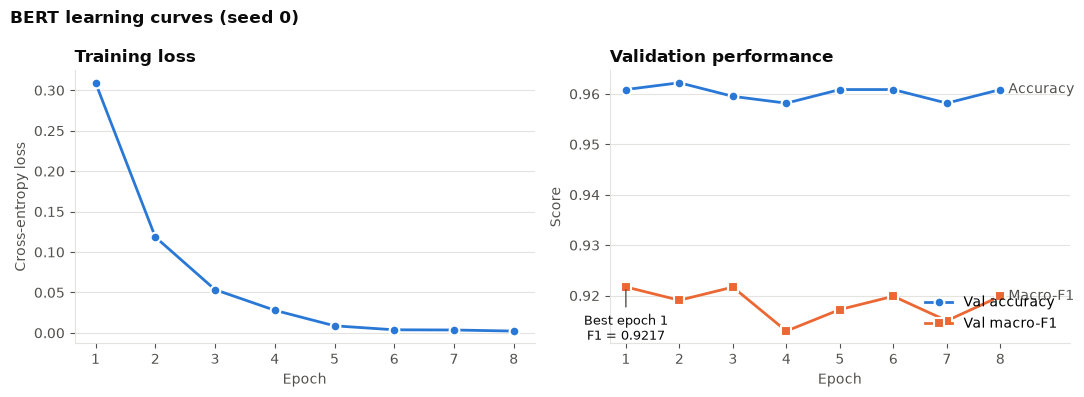

ZeroDivisionError: division by zero

In [14]:
plot_learning_curves(history, title=f'RoBERTa learning curves (seed {SEED})', save_as=f'roberta_learning_curves_seed{SEED}.png')
plot_confusion_matrices(cms, history, save_as=f'roberta_confusion_matrices_seed{SEED}.png')

# 📝 Hyperparameter Tuning Strategy

## Step 1 — Learning Rate
- **What it controls:** Size of each weight adjustment.
- **Impact:** Has the **biggest effect** on BERT fine‑tuning.  
  - A poor LR can ruin training entirely.
- **Plan:** Fix `BATCH_SIZE = 16` and try:
  - `2e-5`
  - `3e-5`
  - `5e-5`

---

## Step 2 — Batch Size
- **What it controls:** How many reviews the model sees before each update.
- **Impact:** Mostly shifts the score slightly, but interacts with LR.
- **Plan:** Using the best LR from Step 1, compare:
  - `BATCH_SIZE = 16`
  - `BATCH_SIZE = 32`

---

## Step 3 — Epochs
- **What it controls:** How many full passes through the training set.
- **Impact:** Depends on LR and batch size; not worth tuning separately.
- **Plan:** Train each run for **4–5 epochs** and read off where validation **macro‑F1 peaks**.  
  - Example: In your 8‑epoch run, performance plateaued after epoch 4.

---

## Practical Note
- **Order matters:** Tune LR first, then batch size, then epochs.  
- **Efficiency:** This saves time by avoiding unnecessary long runs with poor hyperparameters.


# 📊 Metric Trends

| Column        | Meaning                                                                 |
|---------------|-------------------------------------------------------------------------|
| **Train Loss** | How wrong the model is on reviews it learns from (lower is better)      |
| **Val Accuracy** | Share of the 741 held-back reviews it gets right                       |
| **Val Macro-F1** | Score that weights positive and negative reviews equally               |


---

# 📊 Training Results (2e - 5)

## Epoch Metrics
| Epoch | Train Loss | Val Accuracy | Val Macro-F1 | Time |
|-------|------------|--------------|--------------|------|
| 1     | 0.2439     | 0.9474       | 0.8887       | 83s  |
| 2     | 0.0959     | 0.9514       | 0.9087       | 81s  |
| 3     | 0.0438     | 0.9609       | 0.9211       | 79s  |
| 4     | 0.0226     | 0.9622       | 0.9241       | 80s  |


## Classification Report
| Class     | Precision | Recall | F1-Score | Support |
|-----------|-----------|--------|----------|---------|
| Negative  | 0.8704    | 0.8704 | 0.8704   | 108     |
| Positive  | 0.9779    | 0.9779 | 0.9779   | 633     |

**Accuracy:** 0.9622 (741 samples)  
**Macro Avg:** Precision = 0.9241, Recall = 0.9241, F1 = 0.9241  
**Weighted Avg:** Precision = 0.9622, Recall = 0.9622, F1 = 0.9622


---

# 📊 Training Results (3e - 5)

## Epoch Metrics
| Epoch | Train Loss | Val Accuracy | Val Macro-F1 | Time |
|-------|------------|--------------|--------------|------|
| 1     | 0.2360     | 0.9433       | 0.8862       | 80s  |
| 2     | 0.0943     | 0.9595       | 0.9199       | 80s  |
| 3     | 0.0347     | 0.9622       | 0.9217       | 83s  |
| 4     | 0.0182     | 0.9622       | 0.9229       | 83s  |


## Classification Report
| Class     | Precision | Recall | F1-Score | Support |
|-----------|-----------|--------|----------|---------|
| Negative  | 0.8846    | 0.8519 | 0.8679   | 108     |
| Positive  | 0.9749    | 0.9810 | 0.9780   | 633     |

**Accuracy:** 0.9622 (741 samples)  
**Macro Avg:** Precision = 0.9297, Recall = 0.9164, F1 = 0.9229  
**Weighted Avg:** Precision = 0.9617, Recall = 0.9622, F1 = 0.9619

---

# 📊 Training Results (5e - 5)

## Epoch Metrics
| Epoch | Train Loss | Val Accuracy | Val Macro-F1 | Time |
|-------|------------|--------------|--------------|------|
| 1     | 0.2402     | 0.9433       | 0.8904       | 80s  |
| 2     | 0.1002     | 0.9568       | 0.9133       | 83s  |
| 3     | 0.0372     | 0.9555       | 0.9066       | 82s  |
| 4     | 0.0126     | 0.9568       | 0.9112       | 79s  |


## Classification Report
| Class     | Precision | Recall | F1-Score | Support |
|-----------|-----------|--------|----------|---------|
| Negative  | 0.8519    | 0.8519 | 0.8519   | 108     |
| Positive  | 0.9747    | 0.9747 | 0.9747   | 633     |

**Accuracy:** 0.9568 (741 samples)  
**Macro Avg:** Precision = 0.9133, Recall = 0.9133, F1 = 0.9133  
**Weighted Avg:** Precision = 0.9568, Recall = 0.9568, F1 = 0.9568  

---


# 📊 Learning Rate Comparison

| LR    | Best Val Macro-F1 | Best Epoch | Trend                                      |
|-------|-------------------|------------|--------------------------------------------|
| 2e-5  | 0.9241            | 4          | Steadily rising every epoch                 |
| 3e-5  | 0.9229            | 4          | Rising, but flattening after epoch 2        |
| 5e-5  | 0.9133            | 2          | Peaked early, then dropped and wobbled      |


## 📝 Conclusion
- **2e-5**: Safest choice, consistent improvement across epochs.  
- **3e-5**: Acceptable, but gains taper off after epoch 2.  
- **5e-5**: Too aggressive; peaked early and unstable afterwards.  

➡️ For BERT fine‑tuning, **2e-5** is the most reliable LR, with **batch size tuning next** (16 vs 32), followed by epoch selection based on validation F1 plateau.

---

# 📊 Training Results (2e - 5, 32)

## Epoch Metrics
| Epoch | Train Loss | Val Accuracy | Val Macro-F1 | Time |
|-------|------------|--------------|--------------|------|
| 1     | 0.2643     | 0.9420       | 0.8890       | 199s |
| 2     | 0.0948     | 0.9514       | 0.9024       | 146s |
| 3     | 0.0474     | 0.9568       | 0.9119       | 145s |
| 4     | 0.0322     | 0.9609       | 0.9186       | 180s |


## Classification Report
| Class     | Precision | Recall | F1-Score | Support |
|-----------|-----------|--------|----------|---------|
| Negative  | 0.8990    | 0.8241 | 0.8599   | 108     |
| Positive  | 0.9704    | 0.9842 | 0.9773   | 633     |

**Accuracy:** 0.9609 (741 samples)  
**Macro Avg:** Precision = 0.9347, Recall = 0.9041, F1 = 0.9186  
**Weighted Avg:** Precision = 0.9600, Recall = 0.9609, F1 = 0.9602  

---


# 📊 Training Results (3e - 5, 32)

## Epoch Metrics
| Epoch | Train Loss | Val Accuracy | Val Macro-F1 | Time |
|-------|------------|--------------|--------------|------|
| 1     | 0.2473     | 0.9325       | 0.8722       | 240s |
| 2     | 0.0910     | 0.9595       | 0.9174       | 141s |
| 3     | 0.0400     | 0.9622       | 0.9211       | 194s |
| 4     | 0.0246     | 0.9622       | 0.9235       | 181s |


## Classification Report
| Class     | Precision | Recall | F1-Score | Support |
|-----------|-----------|--------|----------|---------|
| Negative  | 0.8774    | 0.8611 | 0.8692   | 108     |
| Positive  | 0.9764    | 0.9795 | 0.9779   | 633     |

**Accuracy:** 0.9622 (741 samples)  
**Macro Avg:** Precision = 0.9269, Recall = 0.9203, F1 = 0.9235  
**Weighted Avg:** Precision = 0.9619, Recall = 0.9622, F1 = 0.9621  

---



# 📦 Batch Size Selection

Batch size controls how many training reviews the model processes before each parameter update.  
- **Smaller batches:** More updates per epoch, each based on fewer samples.  
- **Larger batches:** Fewer, smoother updates, but higher GPU memory usage.  

Following the fine‑tuning range recommended by Devlin et al. [4], we compared **batch sizes of 16 and 32** over 4 epochs.

## Results

| Batch Size | Learning Rate | Updates per Epoch | Best Val Macro-F1 | Negative-Class Recall | Time per Epoch |
|------------|---------------|-------------------|-------------------|-----------------------|----------------|
| 16         | 2e-5          | 417               | 0.9241            | 0.870                 | ~80 s          |
| 32         | 2e-5          | 208               | 0.9186            | 0.824                 | 145–199 s      |
| 32         | 3e-5          | 208               | 0.9235            | 0.861                 | 141–240 s      |

## Observations
- **Batch size 32 (LR 2e-5):** Under‑trained. Validation macro‑F1 was still rising at epoch 4, finishing **0.0055 below batch size 16**.  
  - Negative‑class recall dropped from **0.870 → 0.824**, misclassifying ~5 more of the 108 negative reviews.  
- **Batch size 32 (LR 3e-5):** Closed the gap but gave no gain. Macro‑F1 reached **0.9235**, statistically tied with batch size 16 (0.9241) given ~0.005 run‑to‑run variation.  
- **Training time:** Batch size 32 roughly doubled epoch time.  
  - On an **8 GB GPU** (sequence length 256), batch size 16 used ~3.2 GB GPU memory.  
  - Batch size 32 nearly filled 8 GB, spilling into slower shared memory. Epoch times rose to **141–240 s** and became inconsistent.  
- **Batch size 64:** Not tested. Exceeds recommended range [4], would not fit in 8 GB without gradient accumulation, and would reduce updates to ~104 per epoch, requiring LR/epoch retuning.

## 📝 Conclusion
We selected **batch size 16**:
- Achieved the **highest validation macro‑F1 (0.9241)**.  
- Best **negative‑class recall (0.870)**.  
- Trained about **twice as fast** as batch size 32 on our hardware.  
- Required **no learning‑rate adjustment**.  

Batch size 32 offered no accuracy benefit even with LR tuning, so it was not worth the extra memory use and training time.

---


# 📊 Training Results (8 Epochs, 1st run)

## Epoch Metrics
| Epoch | Train Loss | Val Accuracy | Val Macro-F1 | Time |
|-------|------------|--------------|--------------|------|
| 1     | 0.2736     | 0.9339       | 0.8667       | 84s  |
| 2     | 0.1109     | 0.9487       | 0.9055       | 80s  |
| 3     | 0.0521     | 0.9514       | 0.9060       | 78s  |
| 4     | 0.0232     | 0.9649       | 0.9295       | 81s  |
| 5     | 0.0076     | 0.9649       | 0.9290       | 82s  |
| 6     | 0.0044     | 0.9663       | 0.9304       | 83s  |
| 7     | 0.0005     | 0.9609       | 0.9205       | 81s  |
| 8     | 0.0003     | 0.9663       | 0.9304       | 82s  |


## Classification Report
| Class     | Precision | Recall | F1-Score | Support |
|-----------|-----------|--------|----------|---------|
| Negative  | 0.9109    | 0.8519 | 0.8804   | 108     |
| Positive  | 0.9750    | 0.9858 | 0.9804   | 633     |

**Accuracy:** 0.9663 (741 samples)  
**Macro Avg:** Precision = 0.9429, Recall = 0.9188, F1 = 0.9304  
**Weighted Avg:** Precision = 0.9657, Recall = 0.9663, F1 = 0.9658

---

# 📊 Training Results (8 Epochs, 2nd run)

## Epoch Metrics
| Epoch | Train Loss | Val Accuracy | Val Macro-F1 | Time |
|-------|------------|--------------|--------------|------|
| 1     | 0.2718     | 0.9420       | 0.8802       | 82s  |
| 2     | 0.1094     | 0.9379       | 0.8872       | 81s  |
| 3     | 0.0603     | 0.9555       | 0.9102       | 80s  |
| 4     | 0.0285     | 0.9582       | 0.9130       | 81s  |
| 5     | 0.0129     | 0.9609       | 0.9229       | 79s  |
| 6     | 0.0067     | 0.9636       | 0.9260       | 80s  |
| 7     | 0.0018     | 0.9595       | 0.9187       | 80s  |
| 8     | 0.0001     | 0.9595       | 0.9174       | 79s  |


## Classification Report
| Class     | Precision | Recall | F1-Score | Support |
|-----------|-----------|--------|----------|---------|
| Negative  | 0.8857    | 0.8611 | 0.8732   | 108     |
| Positive  | 0.9764    | 0.9810 | 0.9787   | 633     |

**Accuracy:** 0.9636 (741 samples)  
**Macro Avg:** Precision = 0.9311, Recall = 0.9211, F1 = 0.9260  
**Weighted Avg:** Precision = 0.9632, Recall = 0.9636, F1 = 0.9633  

---


# 📊 Training Results (8 Epochs, 3rd run)

## Epoch Metrics
| Epoch | Train Loss | Val Accuracy | Val Macro-F1 | Time |
|-------|------------|--------------|--------------|------|
| 1     | 0.2774     | 0.9420       | 0.8793       | 80s  |
| 2     | 0.1128     | 0.9501       | 0.9051       | 78s  |
| 3     | 0.0530     | 0.9541       | 0.9079       | 81s  |
| 4     | 0.0267     | 0.9582       | 0.9085       | 79s  |
| 5     | 0.0097     | 0.9582       | 0.9163       | 81s  |
| 6     | 0.0045     | 0.9555       | 0.9026       | 81s  |
| 7     | 0.0012     | 0.9555       | 0.9066       | 79s  |
| 8     | 0.0004     | 0.9595       | 0.9161       | 78s  |

## Classification Report
| Class     | Precision | Recall | F1-Score | Support |
|-----------|-----------|--------|----------|---------|
| Negative  | 0.8532    | 0.8611 | 0.8571   | 108     |
| Positive  | 0.9763    | 0.9747 | 0.9755   | 633     |

**Accuracy:** 0.9582 (741 samples)  
**Macro Avg:** Precision = 0.9147, Recall = 0.9179, F1 = 0.9163  
**Weighted Avg:** Precision = 0.9583, Recall = 0.9582, F1 = 0.9582  

---


# 📊 Training Results (8 Epochs, 4th run)

## Epoch Metrics
| Epoch | Train Loss | Val Accuracy | Val Macro-F1 | Time |
|-------|------------|--------------|--------------|------|
| 1     | 0.2746     | 0.9406       | 0.8798       | 80s  |
| 2     | 0.1123     | 0.9501       | 0.9031       | 76s  |
| 3     | 0.0580     | 0.9474       | 0.8896       | 82s  |
| 4     | 0.0303     | 0.9501       | 0.8878       | 81s  |
| 5     | 0.0114     | 0.9568       | 0.9146       | 80s  |
| 6     | 0.0060     | 0.9555       | 0.9050       | 80s  |
| 7     | 0.0017     | 0.9609       | 0.9211       | 80s  |
| 8     | 0.0002     | 0.9595       | 0.9181       | 81s  |


## Classification Report
| Class     | Precision | Recall | F1-Score | Support |
|-----------|-----------|--------|----------|---------|
| Negative  | 0.8692    | 0.8611 | 0.8651   | 108     |
| Positive  | 0.9763    | 0.9779 | 0.9771   | 633     |

**Accuracy:** 0.9609 (741 samples)  
**Macro Avg:** Precision = 0.9227, Recall = 0.9195, F1 = 0.9211  
**Weighted Avg:** Precision = 0.9607, Recall = 0.9609, F1 = 0.9608  

---



Looks like 5 epochs is the best?

**Validation on Test.json**

In [ ]:
SEED       = 42
MODEL_NAME = 'roberta-base'
MAX_LEN    = 256
BATCH_SIZE = 16
EPOCHS     = 5      # best epoch kept by validation macro-F1
LR         = 2e-5

In [ ]:
@torch.no_grad()
def predict_proba(loader):
    model.eval(); probs = []
    for batch in loader:
        ids, mask = batch[0].to(device), batch[1].to(device)
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=device.type == 'cuda'):
            logits = model(input_ids=ids, attention_mask=mask).logits
        probs.append(torch.softmax(logits.float(), dim=-1)[:, 1].cpu())
    return torch.cat(probs).numpy()

test_prob = predict_proba(test_loader)            # probability the review is positive
test_pred = (test_prob >= 0.5).astype(int)

# Submission file (same format as the template)
submission = pd.DataFrame({'reviews': test_df['reviews'], 'predictions': test_pred})
submission.to_csv('submission_roberta.csv', index=False)
print('Saved submission.csv:', submission.shape)
print(submission['predictions'].value_counts().rename({1: 'positive', 0: 'negative'}))

# Look at the results
results = test_df.assign(pred=test_pred, p_positive=test_prob.round(3))
pd.set_option('display.max_colwidth', 250)

Saved submission.csv: (1851, 2)
predictions
positive    1602
negative     249
Name: count, dtype: int64


In [ ]:
results.sort_values('p_positive', ascending=False).head(5) 

,reviews,pred,p_positive
23,This is one of the best and confortable shoes I've had. Thanks Rockport !!,1,1.0
1835,Love these! Fit is very true to size. They are super comfortable- nice arch,1,1.0
1237,This is a lightweight skirt that fits great. The red color is so vibrant and I like the contrast of the white piping on the side. Great addition to any tennis player's wardrobe,1,1.0
1239,"Soft, silky, and stretchy - I just love wearing these. They are the most comfortable underwear I own, and they fit perfectly. I can't wait for more of my old underwear to wear out so I can replace them with these",1,1.0
29,These life stride shoes fit like a glove! They don't pinch and they were made with quality. I really like these,1,1.0


In [ ]:
results.sort_values('p_positive').head(5)

,reviews,pred,p_positive
1823,"Although very cute, Crocs are not good shoes. They are a cheap, plastic shoe that is over priced and NOT comfortable at all. I bought a pair for my two year old daughter because of the ease to clean them and because they are ""non slip"". She di...",0,0.001
464,"Poor product. No strap comes with this case. Too difficult to get the iPod out for updates, whilst trying to pull out iPod can be dropped. Front view cover is smeary and scratched. Buttons are difficult to re-snap. No need for other voting o...",0,0.001
969,"TERRIBLE BRA. WHAT I MISTAKE I MADE THINKING THIS WOULD WORK OUT FOR ME.\n\nTERRIBLE FIT, NOT MADE FOR DD CUPS OR FOR THAT MATTER ANYONE OVER A B CUP....\n\nVERY DISAPPOINTED....",0,0.001
899,This shoe is very uncomfortable. The pinky toe gets caught between the straps and it hurts very badly. I tried to give them to my aunt and she would not take them for free,0,0.001
1700,"I was very disappointed with this bra. I would definately not recommend it. If you are looking for a good and supportive nursing bra try the Maternelle bra instead.\n\nThis bra looks sexy, but does not offer the support and coverage needed for ...",0,0.001


In [ ]:
results.iloc[(results['p_positive'] - 0.5).abs().argsort()].head(10)

,reviews,pred,p_positive
1283,"The scarves were good quality but I should have paid more attention to previous reviewers on this gift.\nthe pack had about 5 or 6 black scarves and a couple other colors, nothing like the picture. save your dough on these scarves",1,0.539
560,"I am an experienced lightsaber fighter and Star Wars fan. When I ordered this saber, I expected it to be hard and sturdy, like the basic sabers. It's electronic all right, but it trades that for quality. The blade is made of flimsy plastic, and d...",0,0.449
1647,I bought these for my husband and the color said rinse so I thought regular jean color. In fact they were so dark that they almost look black. I have washed then about 5 times but they won't fade,0,0.420
1678,"We are very happy with the gazebo and will be excited to use this next football season. \nUnfortunately, the cover came with some stitching missing and we have not been able to receive any response from Amazon after sending 4 emails. We do not ...",1,0.599
1504,According to the write up a 46 inch belt should comfortably fit a 48 inch waist. This is not the case. Apart from that an attractive belt,0,0.378
793,"I just mailed those back this past week to Beall's in Florida. However,\nwhen the mailman took it from my mailbox (I am 83 and no car) he brought it back the next day because of insufficient postage on it. There was $l.71 due. So, I put (5) 3...",0,0.375
343,"My wife has purchased and worn this style for many years; however, the items received were nothing like the picture. The pictured item was exactly what she wanted, lace waistband AT (not below) her waist and high-cut leg openings; the delivered ...",0,0.370
573,Turn around time to receive item was good. Material of the shirt was sub-par (very thin) for the price.,1,0.635
456,"Ah. The anti-statement statement bracelet. Nice.\n\nHere's a thought to those who find this in bad taste: instead of spending your time criticizing others, or wearing a cheap bracelet that supposedly speaks to your COMMITMENT to various causes; w...",1,0.643
577,"I bought 5 pairs, had to return 1 because the legs were different lengths. The 4 remaining were much too long--the ends of the pants were under my heels. I knew they'd shrink, but despite washing them in cold water and drying them on medium or ...",1,0.682
